Material tests and fitted models

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

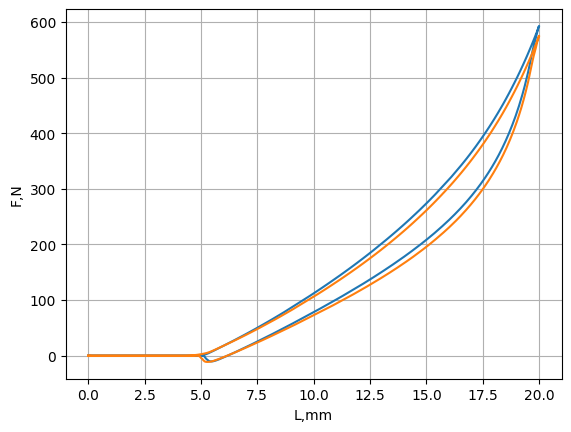

In [27]:
def read_data(filename):
    return np.loadtxt(
        filename,
        delimiter="\t",skiprows=3,
        converters=lambda x: float(x.replace(",", ".")))

c_data_1 = read_data("txtfiles/COMPR1.tab")
c_data_2 = read_data("txtfiles/COMPR2.tab")
c_data_3 = read_data("txtfiles/COMPR3.tab")

F1=c_data_1[:,0]
L1=c_data_1[:,1]
T1=c_data_1[:,2]

F2 = c_data_2[:,0]
L2=c_data_2[:,1]
T2=c_data_2[:,2]

l1_min_pos = np.where(L1==5.0)[0][0]
l2_min_pos = np.where(L1==5.0)[0][0]
l1max_pos = np.where(L1 == max(L1))[0][0]
l2max_pos = np.where(L2 == max(L2))[0][0]

L1cut = L1[l1_min_pos:l1max_pos]
F1cut = F1[l1_min_pos:l1max_pos]

L2cut = L2[l2_min_pos:l2max_pos]
F2cut = F2[l2_min_pos:l2max_pos]

fig1,ax1 = plt.subplots()

ax1.plot(L1,F1)
ax1.plot(L2,F2)

ax1.set_xlabel("L,mm")
ax1.set_ylabel("F,N")
ax1.grid()

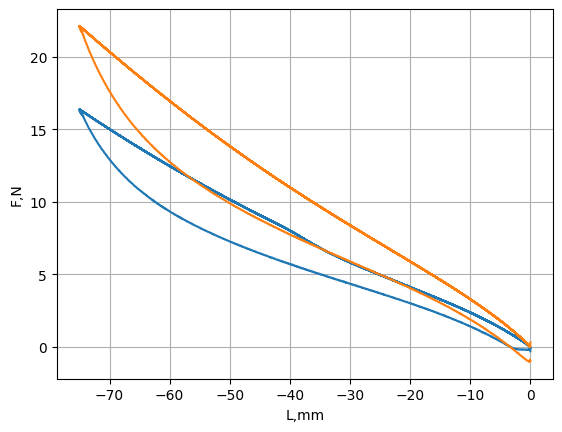

In [ ]:
t_data_1 = read_data("txtfiles/TENS1.tab")
t_data_2 = read_data("txtfiles/TENS2.tab")
t_data_3 = read_data("txtfiles/TENS3.tab")

F1=t_data_1[:,0]
L1=t_data_1[:,1]
T1=t_data_1[:,2]

F2 = t_data_2[:,0]
L2=t_data_2[:,1]
T2=t_data_2[:,2]

"""
l1_min_pos = np.where(L1==5.0)[0][0]
l2_min_pos = np.where(L1==5.0)[0][0]
l1max_pos = np.where(L1 == max(L1))[0][0]
l2max_pos = np.where(L2 == max(L2))[0][0]

L1cut = L1[l1_min_pos:l1max_pos]
F1cut = F1[l1_min_pos:l1max_pos]

L2cut = L2[l2_min_pos:l2max_pos]
F2cut = F2[l2_min_pos:l2max_pos]
"""

fig1,ax1 = plt.subplots()

ax1.plot(L1,F1)
ax1.plot(L2,F2)

ax1.set_xlabel("L,mm")
ax1.set_ylabel("F,N")
ax1.grid()

Dimless values

exp data: (array([ 5.   ,  5.003,  5.005, ..., 19.993, 19.995, 19.998], shape=(6000,)), array([5.639000e-01, 5.471000e-01, 5.756000e-01, ..., 5.916259e+02,
       5.919001e+02, 5.921590e+02], shape=(6000,)), array([0.0000e+00, 5.0000e-03, 1.0000e-02, ..., 2.9985e+01, 2.9990e+01,
       2.9995e+01], shape=(6000,)))
exp data dimless: [array([166.39861065, 166.49784982, 166.56400926, ..., 662.36288455,
       662.429044  , 662.52828316], shape=(6000,)), array([8.21281368e+02, 7.96813329e+02, 8.38321609e+02, ...,
       8.61662225e+05, 8.62061578e+05, 8.62438648e+05], shape=(6000,))]


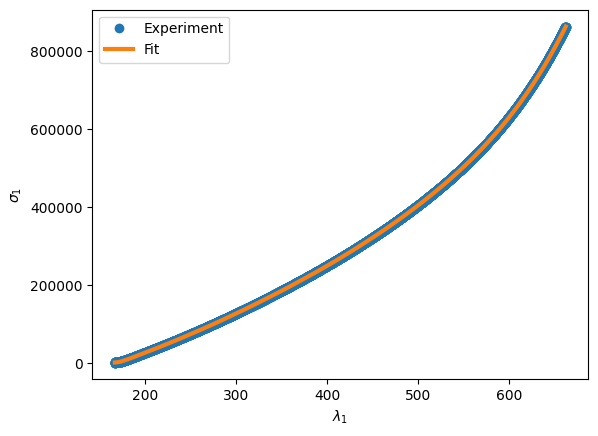

In [29]:
from pathlib import Path

BASE_DIR = Path.cwd()

def plot_data(data_exp, data_fit):
    """
    Plot experimental and fitted uniaxial data.

    Parameters
    ----------
    data_exp : tuple
        (lambda1, sigma1) experimental data.

    data_fit : tuple
        (lambda1, sigma1) fitted data.
    """

    fig, ax = plt.subplots()

    ax.plot(data_exp[0],data_exp[1],"o",label="Experiment",)

    ax.plot(data_fit[0],data_fit[1],"-",linewidth=3,label="Fit",)

    ax.set_xlabel(r"$\lambda_1$")
    ax.set_ylabel(r"$\sigma_1$")
    ax.legend()

    plt.show()

def read_exp_data(filename):
    data = np.loadtxt(filename,delimiter="\t",skiprows=3,
        converters=lambda x: float(x.replace(",", ".")))
    F=data[:,0]
    L=data[:,1]
    T=data[:,2]

    l_min_pos = np.where(L==5.0)[0][0]
    lmax_pos = np.where(L==max(L))[0][0]

    Lcut = L[l_min_pos:lmax_pos]
    Fcut = F[l_min_pos:lmax_pos]
    Tcut = T[l_min_pos:lmax_pos]
    Tcut -= Tcut[0]

    #return np.column_stack((Lcut, Fcut, Tcut))
    return (Lcut,Fcut,Tcut)

def dimensioned_to_dimensionless(data,A0,L0):
    # L to lambda, lambda=L/L0
    # F to sigma, sigma=F/A0
    return [(data[0]+L0)/L0,data[1]/A0]


A0CYLMEAN=686.61e-6
L0CYLMEAN=30.23e-3
A0RECTMEAN=30.62e-6
L0RECTMEAN=25.00e-3

filename1 = BASE_DIR / "txtfiles" / "COMPR1.tab"
exp_data = read_exp_data(filename1)
print(f"exp data: {exp_data}")
exp_data_dimless = dimensioned_to_dimensionless(exp_data,A0CYLMEAN,L0CYLMEAN)
print(f"exp data dimless: {exp_data_dimless}")

plot_data(exp_data_dimless,exp_data_dimless)